# Synthetic Benchmark datasets


In [5]:
library(tidyverse)
library(ggplot2)

Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [6]:
# Read qc table from file
dt <- read_tsv("../../assembly/qc/qc_benchmark.tsv", show_col_types = FALSE)
head(dt)

metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
Number of mapped sequences,59,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of primary alignments,1429,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of secondary alignments,102,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of primary alignments with >65535 CIGAR operations,0,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of bases in mapped sequences,64585949,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of mapped bases,63548451,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA


In [9]:
print(paste("Rows unprocessed:", nrow(dt)))
source("../scripts/13_process_assembly_qc.R")

dt_processed <- process_qc_table(dt) %>% mutate(haplotype = ifelse(is.na(haplotype), "both", haplotype))
print(paste("Rows processed:", nrow(dt_processed)))


[1] "Rows unprocessed: 9692"
[1] "Rows processed: 1380"


In [10]:
# Create new column seqtype with either duplex, herro or combined
dt_reduced_typed <- dt_processed %>%
  filter(str_detect(asm_name, "published")) %>%
  filter(!str_detect(asm_name, "nopolish")) %>%
  filter(asm_method=="phased_verkko") %>%
  mutate(
    seq_type = case_when(
      str_detect(asm_name, "duplex") ~ "duplex",
      str_detect(asm_name, "herro") ~ "herro",
      str_detect(asm_name, "combined") ~ "combined",
      TRUE ~ NA_character_
    ),
    asm_name = str_remove(asm_name, "duplex|herro") %>%
        str_replace("__", "_") %>%
        str_remove_all("_$")
  )

### Compare duplex to herro

We will both compare the subsampled chr19 datasets and the full

#### Full assemblies

In [11]:
dt_HvD_full <- dt_reduced_typed %>% filter(asm_name == "published")

Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_bar()`).”


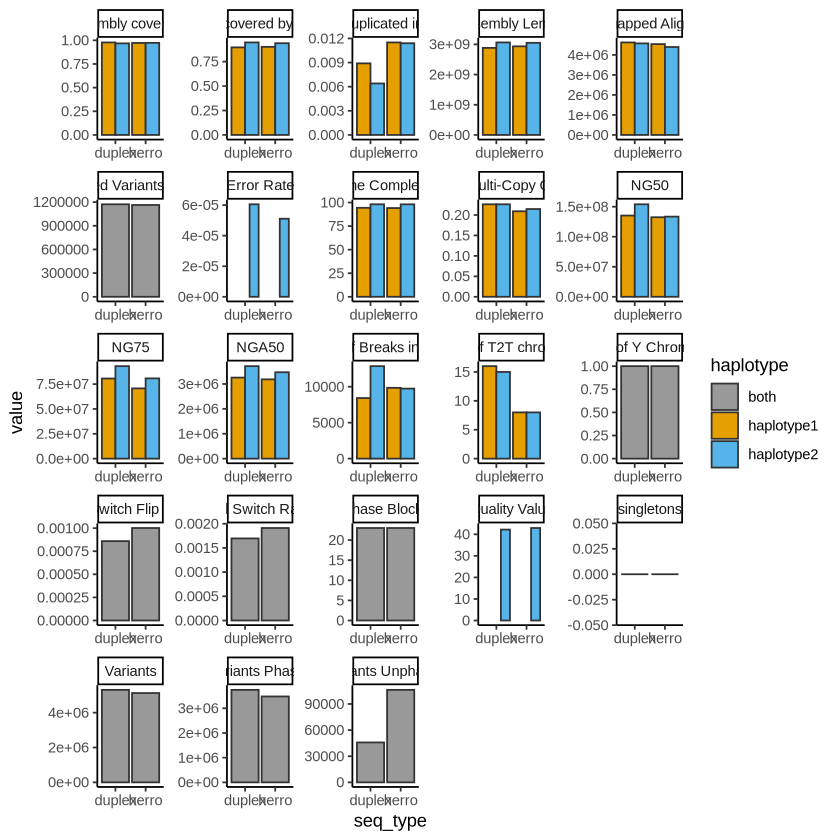

In [12]:
dt_HvD_full  %>% 
    ggplot(aes(x = seq_type, y = value, fill = haplotype)) + 
        facet_wrap(~metric, scales = "free") + 
        geom_bar(stat = "identity",position = "dodge", col = "grey20") +
        # Okabe-Ito palette (colorblind friendly)
        scale_fill_manual(values = c("#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442")) +
        theme_classic()

In [14]:
dt_HvD_full %>%
  filter(asm_name == "published") %>%
  group_by(seq_type, metric, haplotype, source) %>%
  summarise(value = sum(value, na.rm = TRUE), .groups = 'drop') %>%
  mutate(
    formatted_value = case_when(

      metric %in% c("Error Rate") ~ paste0(round(value * 100, 3), "%"),
      TRUE ~ as.character(round(value, 2))
    )
  ) %>%
  select(-value) %>%  # Remove original value column
  pivot_wider(
    names_from = seq_type, 
    values_from = formatted_value
  ) %>%
  arrange(source, metric, haplotype) %>%
  knitr::kable()



|metric                            |haplotype  |source                      |duplex     |herro      |
|:---------------------------------|:----------|:---------------------------|:----------|:----------|
|Genome Completeness               |haplotype1 |asmgene                     |94.41      |94.16      |
|Genome Completeness               |haplotype2 |asmgene                     |98.14      |98.09      |
|Missing Multi-Copy Genes (%)      |haplotype1 |asmgene                     |0.23       |0.21       |
|Missing Multi-Copy Genes (%)      |haplotype2 |asmgene                     |0.23       |0.21       |
|% of Assembly covered by Ref      |haplotype1 |asmstat                     |0.98       |0.97       |
|% of Assembly covered by Ref      |haplotype2 |asmstat                     |0.97       |0.97       |
|% of Ref covered by Assembly      |haplotype1 |asmstat                     |0.9        |0.9        |
|% of Ref covered by Assembly      |haplotype2 |asmstat                     |0.9

Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_bar()`).”


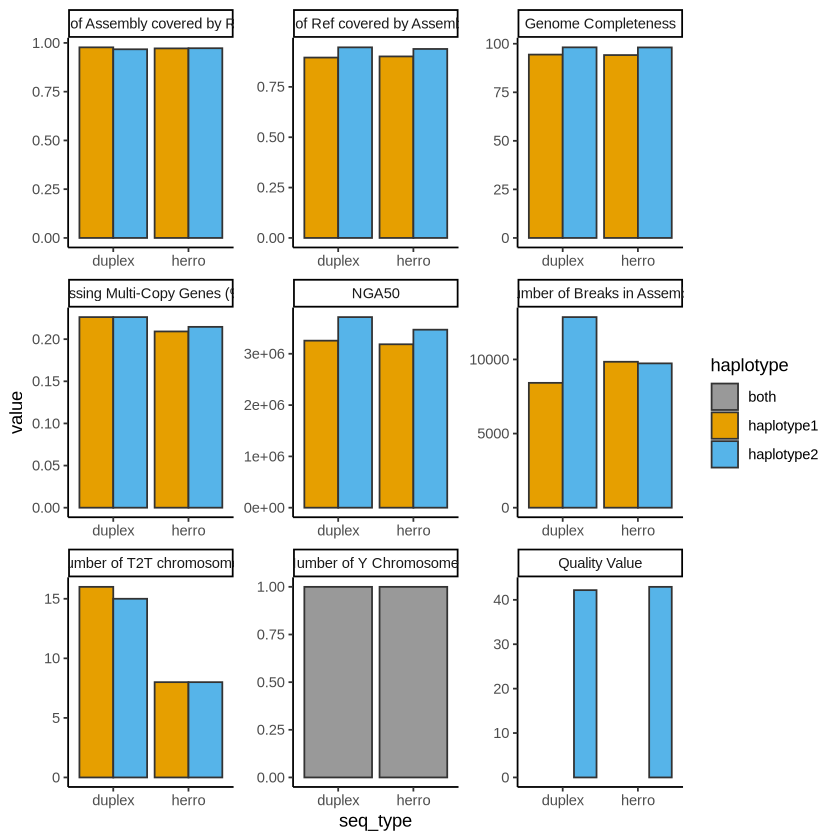

In [15]:
dt_HvD_full  %>% 
    filter(metric %in% c(
        "Genome Completeness",
         "Missing Multi-Copy Genes (%)",
         "% of Assembly covered by Ref",
         "% of Ref covered by Assembly",
         "NGA50",
         "Number of Breaks in Assembly",
         "Switch Error", "Quality Value", 
         "Number of T2T chromosomes",
         "Number of Y Chromosomes"
         )) %>%
    ggplot(aes(x = seq_type, y = value, fill = haplotype)) +
        facet_wrap(~metric, scales = "free") + 
        geom_bar(stat = "identity",position = "dodge", col = "grey20") +
        # Okabe-Ito palette (colorblind friendly)
        scale_fill_manual(values = c("#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442")) +
        theme_classic()

In the published dataset it looks like the duplex assembly is better then herro, especially in finding complete T2T chromosomes.

### Compare chr19 assemblies

In [18]:
dt_reduced_typed %>% 
    filter(str_detect(asm_name, 'chr19')) %>%
    pull(asm_name) %>% unique %>% print

 [1] "published_chr19_15x"         "published_chr19_20x"        
 [3] "published_chr19_25x"         "published_chr19_combined35x"
 [5] "published_chr19_UL50x"       "published_chr19_UL70x"      
 [7] "published_chr19_UL90x"       "published_chr19_35x_UL70x"  
 [9] "published_chr19_35x_UL90x"   "published_chr19_60x_UL50x"  
[11] "published_chr19_60x_UL70x"   "published_chr19_60x_UL90x"  
[13] "published_chr19_120x_UL50x"  "published_chr19_120x_UL70x" 
[15] "published_chr19_120x_UL90x" 


In [20]:
dt_reduced_typed %>%
    filter(str_detect(asm_name, 'chr19')) %>%
    mutate(type = case_when(
        str_detect(asm_name, "duplex") ~ "duplex",
        str_detect(asm_name, "herro") ~ "herro",
        str_detect(asm_name, "combined") ~ "combined",
        TRUE ~ "other"
    ))


metric,value,haplotype,asm_method,asm_name,source,chromosome,seq_type,type
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Assembly Length,6.015058e+07,haplotype1,phased_verkko,published_chr19_15x,asmstat,NA,duplex,other
% of Ref covered by Assembly,8.990000e-01,haplotype1,phased_verkko,published_chr19_15x,asmstat,NA,duplex,other
% of Ref duplicated in Assembly,2.900000e-03,haplotype1,phased_verkko,published_chr19_15x,asmstat,NA,duplex,other
% of Assembly covered by Ref,9.214000e-01,haplotype1,phased_verkko,published_chr19_15x,asmstat,NA,duplex,other
NG75,4.735506e+07,haplotype1,phased_verkko,published_chr19_15x,asmstat,NA,duplex,other
NG50,4.735506e+07,haplotype1,phased_verkko,published_chr19_15x,asmstat,NA,duplex,other
NGA50,1.547165e+06,haplotype1,phased_verkko,published_chr19_15x,asmstat,NA,duplex,other
Average Ungapped Alignment length,2.168993e+06,haplotype1,phased_verkko,published_chr19_15x,asmstat,NA,duplex,other
Number of Breaks in Assembly,7.480000e+02,haplotype1,phased_verkko,published_chr19_15x,asmstat,NA,duplex,other



## Compare with and without verkko polishing

In [32]:
id_polished <- c(
    "published_chr19_combined35x",
    "published_chr19_combined35x_nopolish",
    "published_chr19_duplex_UL50x",
    "published_chr19_duplex_UL50x_nopolish",
    "published_chr19_herro_35x_UL50x",
    "published_chr19_herro_35x_UL50x_nopolish"
)

dt_polished <- dt %>%
    filter(asm_name %in% id_polished)


print(paste("Rows unprocessed:", nrow(dt_polished)))
source("../scripts/13_process_assembly_qc.R")

dt_polished_processed <- process_qc_table(dt_polished) %>% mutate(haplotype = ifelse(is.na(haplotype), "both", haplotype))
print(paste("Rows processed:", nrow(dt_polished_processed)))

dt_polished_processed %>%
  select(metric, value, haplotype, asm_name) %>%
  pivot_wider(
    names_from = asm_name,
    values_from = value
  ) %>%
  knitr::kable()


[1] "Rows unprocessed: 1520"


[1] "Rows processed: 340"


Warning message:
“Values from `value` are not uniquely identified; output will contain list-cols.
• Use `values_fn = list` to suppress this warning.
• Use `values_fn = {summary_fun}` to summarise duplicates.
• Use the following dplyr code to identify duplicates.
  {data} |>
  dplyr::summarise(n = dplyr::n(), .by = c(metric, haplotype, asm_name)) |>
  dplyr::filter(n > 1L)”




|metric                            |haplotype  |published_chr19_combined35x |published_chr19_combined35x_nopolish |published_chr19_duplex_UL50x |published_chr19_duplex_UL50x_nopolish |published_chr19_herro_35x_UL50x_nopolish |
|:---------------------------------|:----------|:---------------------------|:------------------------------------|:----------------------------|:-------------------------------------|:----------------------------------------|
|Assembly Length                   |haplotype1 |62324541, 61224283          |62324541, 61224283                   |61059006, 61558390           |61059006, 61558390                    |61197534, 60257627                       |
|% of Ref covered by Assembly      |haplotype1 |0.9217, 0.9350              |0.9217, 0.9350                       |0.9319, 0.9243               |0.9319, 0.9243                        |0.9213, 0.9229                           |
|% of Ref duplicated in Assembly   |haplotype1 |0.0137, 0.0021              |0.0137, 0.002

QC results look identical!